## Behavior Score calculation - same reward cues session

In [1]:
from ImageAnal import *
%matplotlib inline

#### Load session data

In [2]:
datapath = os.getcwd() + '/' #current working directory - look for data and strings here!
date_time = '2025-01-23_11-02-24' # date and time of the imaging session
name = 'srb504' # mouse name
task = 'NearFarLong' # task name

## locate the suite2p folder
suite2p_folder = datapath + 'data/' + name + '_imaging/srb504_250123/'

## the name and location of the imaging log file
imaging_logfile_name = suite2p_folder + 'srb504_250123-001.xml'

## the name and location of the trigger voltage file
TRIGGER_VOLTAGE_FILENAME = suite2p_folder + 'srb504_250123-001_Cycle00001_VoltageRecording_001.csv'

In [3]:
D1 = ImagingSessionData(datapath, date_time, name, task, suite2p_folder, imaging_logfile_name, TRIGGER_VOLTAGE_FILENAME)

relevant behavior located, lap time of the first frame: 238.056121
   slight warning - testing some late candidates failed
suite2p data loaded
corrected offset: 238.05312100000037 voltage_delay: 0.00299999999970169
single-plane
suite2p time axis loaded
calculating dF/F and SNR...
SNR done
dF/F calculated for cell ROI-s
ExpStateMachineLog time interval > 1s:  23  times
length of frame_times: 35576
length of frame_laps: 35576
shape of dF_F: (1486, 35576)
lap mode = 0
Late-start lap found, first position: 4354.0 in lap 3 in corridor 15
Early end lap found, last position: 1995.49 in lap 105 in corridor 14
Short lap found, we have total  1089 position bins recorded by the ExpStateMachine in a lap before lap 107 in corridor 14
laps with im data:  [  4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21
  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39
  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57
  58  59  60  61  62  63  64  

C:\Users\martin\home\phd\repos\ABmice_behavScoreIntegration\ImageAnal.py:1061: RuntimeWarning: Mean of empty slice
  Fano_factor[i_cell] = np.nanmean(nan_divide(np.nanvar(laps_rates, axis=1), rate_matrix[:,i_cell], rate_matrix[:,i_cell] > 0))


calculating Skaggs spatial info...
calculating proportion of active laps...
calculating proportion of active laps based on dF/F ...
calculating linear tuning specificity ...
calculating rate, reliability and Fano factor...


C:\Users\martin\home\phd\repos\ABmice_behavScoreIntegration\ImageAnal.py:1074: RuntimeWarning: invalid value encountered in double_scalars
  skaggs_vector[i_cell] = np.sum(lambda_x[i_nonzero]*np.log2(lambda_x[i_nonzero]/mean_firing)*P_x[i_nonzero]) / mean_firing
C:\Users\martin\home\phd\repos\ABmice_behavScoreIntegration\ImageAnal.py:1117: RuntimeWarning: invalid value encountered in true_divide
  Px = rr / np.sum(rr)


calculating Skaggs spatial info...
calculating proportion of active laps...
calculating proportion of active laps based on dF/F ...
calculating linear tuning specificity ...
calculating corridor selectivity ...
calculating corridor similarity ...


C:\Users\martin\home\phd\repos\ABmice_behavScoreIntegration\ImageAnal.py:1120: RuntimeWarning: divide by zero encountered in double_scalars
  tuning_spec[i_cell] = self.corridor_length_cm / sigma
C:\Users\martin\home\phd\repos\ABmice_behavScoreIntegration\ImageAnal.py:1152: RuntimeWarning: invalid value encountered in true_divide
  self.cell_corridor_selectivity[0,:] = (max_rate - min_rate) / sumrate
C:\Users\martin\home\phd\repos\ABmice_behavScoreIntegration\ImageAnal.py:1461: RuntimeWarning: divide by zero encountered in double_scalars
  if ( ( (sum(lapsums > 0.6) / float(N_laps_corr)) > 0.2)  & ( (rate_inField / rate_outField) > 7) ):


testing anticipatory licks...
N_corridors:  2
corridors:  [14 15]


#### Behavior score calculation
There are three parameters you can set for the function `calculate_behavior_score`:
- corridor A (here it's 14)
- corridor B (here it's 15)
- and the list of laps you want to restrict the calculation to - if you set it to `None` you will calculate it for all the laps

In [4]:
imaged_laps = D1.i_Laps_ImData
D1.calculate_behavior_score(14, 15, selected_laps=imaged_laps)
D1.behavior_table

,P correct (14),P correct (15),Speed index (14),Speed index (15),Speed selectivity,Lick index (14),Lick index (15),Lick selectivity,BEHAVIOR SCORE
0,1.0,1.0,0.622222,0.311111,0.323513,0.97,0.94,0.961016,6.127863


You can save this table into an Excel if you want:

In [5]:
D1.behavior_table.to_excel(suite2p_folder + "behavior_score_table.xlsx", index=False)

#### Behavior plots
- Red bars indicate the pre-RZ and control zones between which lick and speed _indices_ are calculated within each corridor
- Green bars indicate the selectivity zone where speed and lick _selectivities_ are calculated across the two corridors

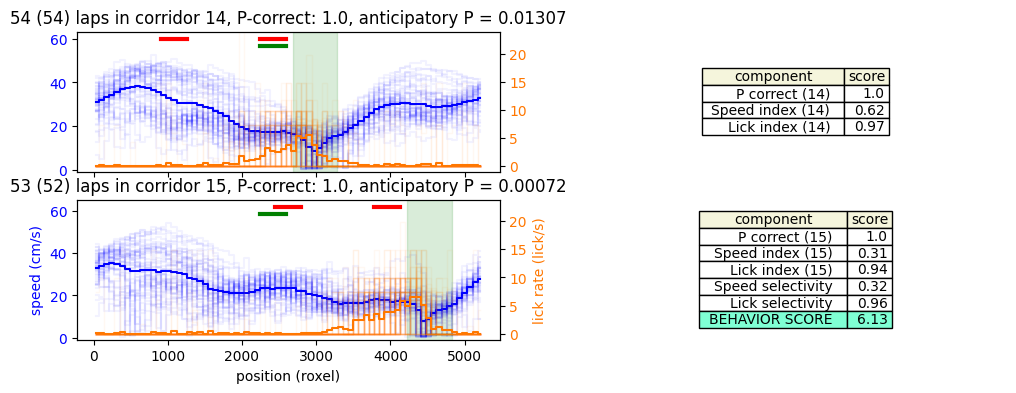

In [6]:
D1.plot_session(average=True)

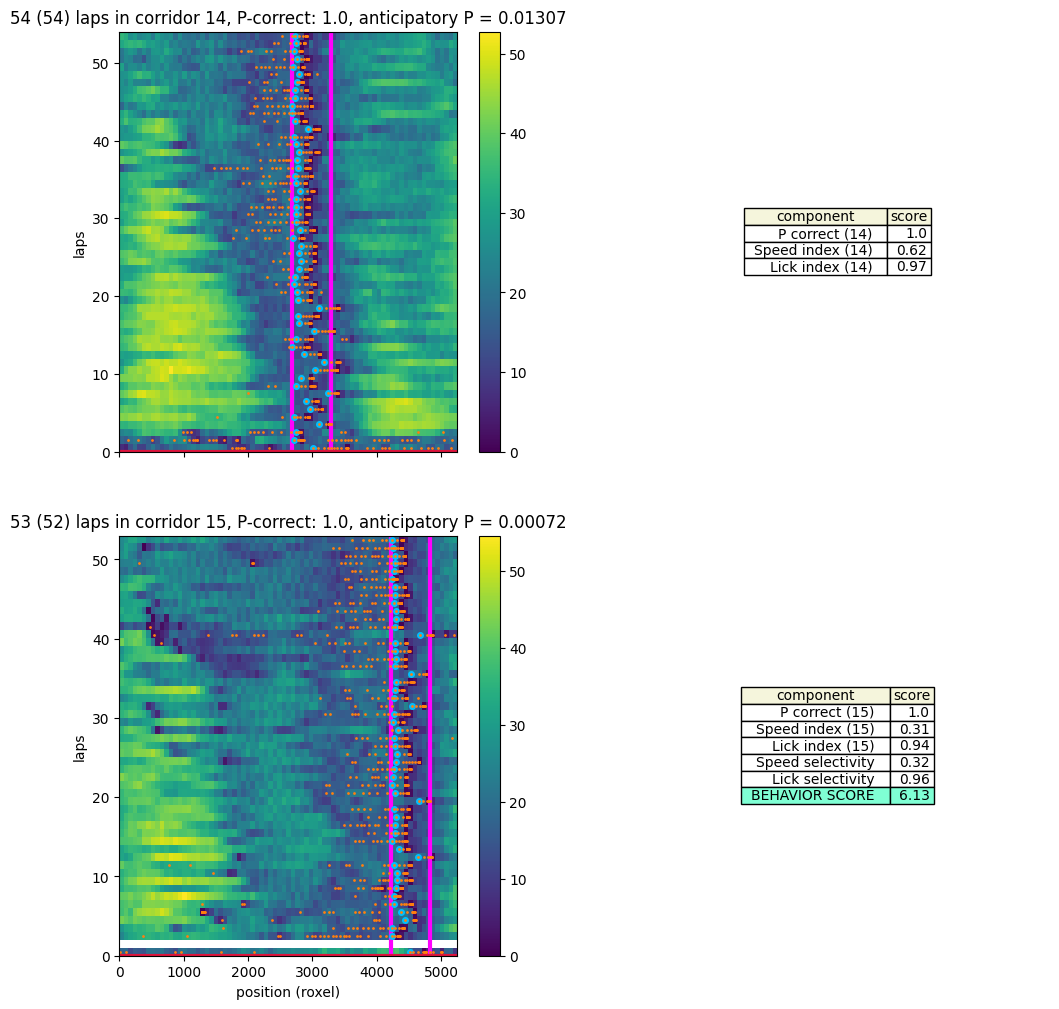

In [7]:
D1.plot_session(average=False)